C:\Users\asdxo\AppData\Local\Temp\ipykernel_13944\2885156755.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=price_report, x='price_range', y='중앙값_흥행_규모', palette='magma', alpha=0.6)


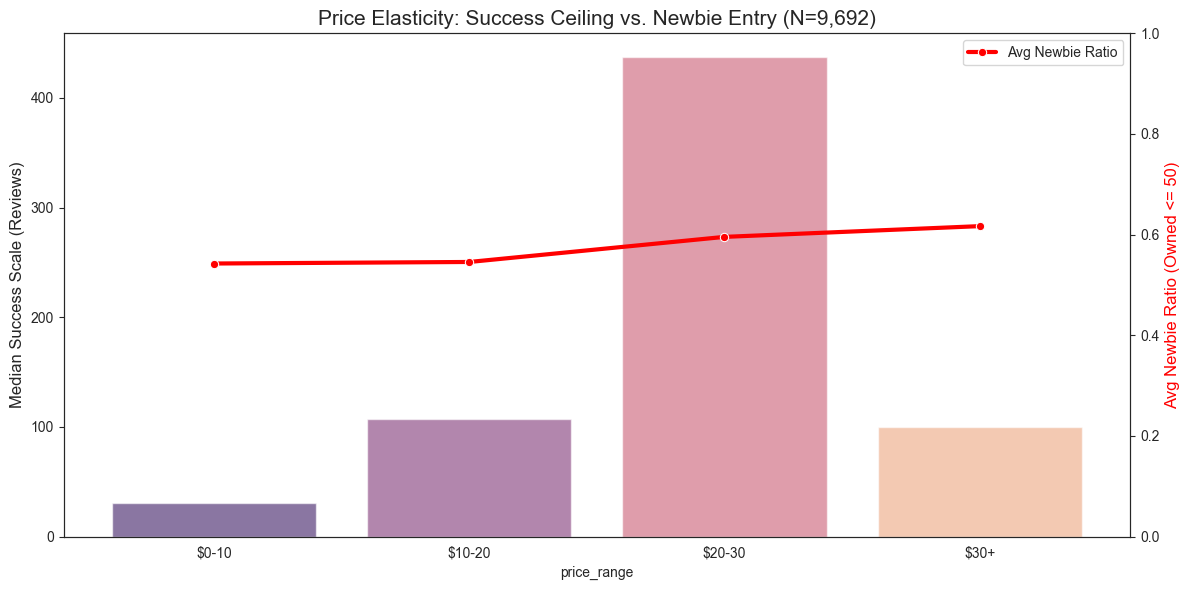


가격 구간별 흥행 성적표 (전수 데이터 기반)
price_range  게임_수  중앙값_흥행_규모  평균_뉴비_비율  평균_긍정률
      $0-10  7081       31.0     0.543  84.379
     $10-20  2158      107.0     0.546  84.021
     $20-30   350      437.0     0.596  81.455
       $30+   103      100.0     0.617  79.258


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (안준환님의 분석 환경 경로 적용)
base_path = '../../../../data/preprocessed/'
df_all = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')
df_reviews = pd.read_csv(f'{base_path}steam_indie_reviews.csv')

# 컬럼 공백 제거 및 타입 정리
df_all.columns = df_all.columns.str.strip()
df_reviews.columns = df_reviews.columns.str.strip()

# 2. 가격 구간(Price Bin) 설정
# 인디 게임 시장의 주요 가격 심리선을 기준으로 분류함
bins = [-1, 10, 20, 30, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df_all['price_range'] = pd.cut(df_all['price'].fillna(0), bins=bins, labels=labels)

# 3. 뉴비 유입 비율 계산 (N=188개 샘플 앱 기반 전수 조사)
# 뉴비 정의: 보유 게임 수 50개 이하 (유저님 분석 기준)
df_reviews['is_newbie'] = df_reviews['author_num_games_owned'] <= 50
newbie_stats = df_reviews.groupby('appid')['is_newbie'].mean().reset_index(name='newbie_ratio')

# 전체 데이터(9,692개)에 뉴비 비율 병합
df_analysis = pd.merge(df_all, newbie_stats, on='appid', how='left')

# 4. 가격 구간별 통계 집계
price_report = df_analysis.groupby('price_range', observed=False).agg(
    게임_수=('appid', 'count'),
    중앙값_흥행_규모=('total_reviews', 'median'),
    평균_뉴비_비율=('newbie_ratio', 'mean'),
    평균_긍정률=('positive_rate', 'mean')
).reset_index()

# 5. 시각화: 흥행 천장 vs 뉴비 유입 상관관계
plt.figure(figsize=(12, 6))
sns.set_style("white")

# 바 차트: 흥행 규모 (중앙값)
ax1 = sns.barplot(data=price_report, x='price_range', y='중앙값_흥행_규모', palette='magma', alpha=0.6)
ax1.set_ylabel('Median Success Scale (Reviews)', fontsize=12)
ax1.set_title('Price Elasticity: Success Ceiling vs. Newbie Entry (N=9,692)', fontsize=15)

# 라인 차트: 뉴비 비율 (우측 Y축)
ax2 = ax1.twinx()
sns.lineplot(data=price_report, x='price_range', y='평균_뉴비_비율', ax=ax2, color='red', marker='o', linewidth=3, label='Avg Newbie Ratio')
ax2.set_ylabel('Avg Newbie Ratio (Owned <= 50)', color='red', fontsize=12)
ax2.set_ylim(0, 1.0) # 비율이므로 0~1 고정

plt.tight_layout()
plt.show()

# 6. 최종 결과 출력
print("\n" + "="*50)
print("가격 구간별 흥행 성적표 (전수 데이터 기반)")
print("="*50)
print(price_report.round(3).to_string(index=False))
print("="*50)

C:\Users\asdxo\AppData\Local\Temp\ipykernel_13944\3873195210.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=price_report, x='price_range', y='성공_천장', ax=ax1, palette='magma', alpha=0.7)


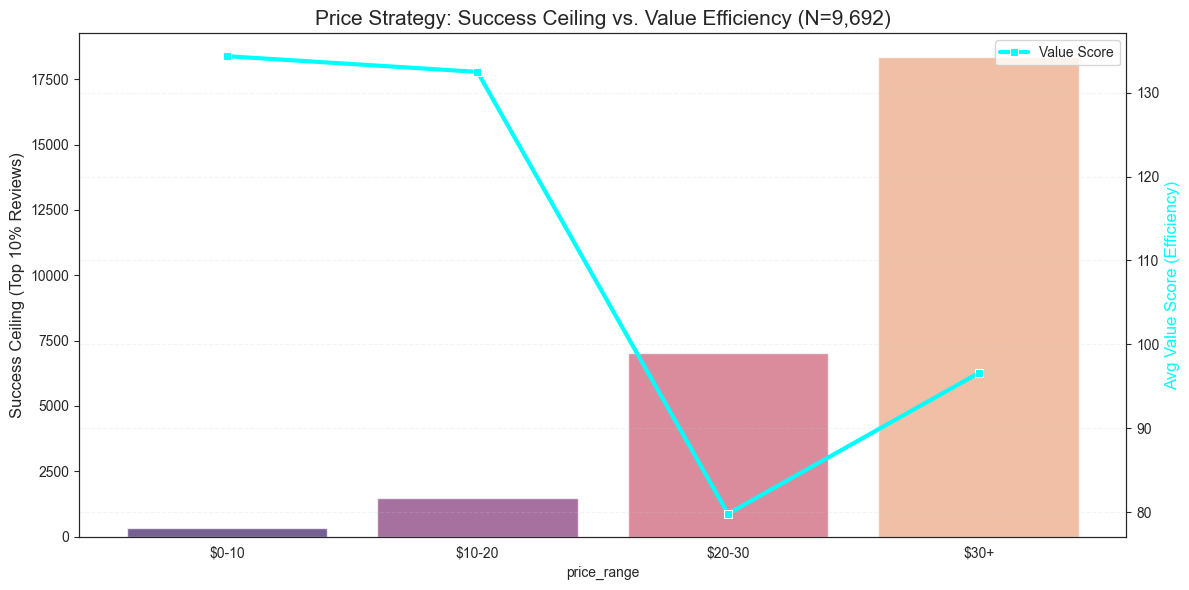


전수 데이터 기반 가격 구간별 흥행/효율 성적표
price_range  게임_수  중앙값_흥행   성공_천장  평균_긍정률  평균_가성비
      $0-10  7081    31.0   333.0  84.379 134.332
     $10-20  2158   107.0  1490.9  84.021 132.465
     $20-30   350   437.0  7044.2  81.455  79.840
       $30+   103   100.0 18341.4  79.258  96.595


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 (경로: ../../../../data/preprocessed/)
base_path = '../../../../data/preprocessed/'
df_all = pd.read_csv(f'{base_path}steam_indie_games_graded.csv')

# 컬럼 공백 제거 및 전처리
df_all.columns = df_all.columns.str.strip()

# [고도화] 가성비 지표 산출: 소유자 대비 실제 추천 비중 (Efficiency)
df_all['value_score'] = df_all['recommendations_total'] / (df_all['owners_lower'] + 1)

# 2. 가격 구간(Price Bin) 설정
bins = [-1, 10, 20, 30, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df_all['price_range'] = pd.cut(df_all['price'].fillna(0), bins=bins, labels=labels)

# 3. 가격 구간별 전수 통계 집계
# 중앙값 외에 상위 10%(90th Percentile) 성적을 '성공 천장'으로 정의
price_report = df_all.groupby('price_range', observed=False).agg(
    게임_수=('appid', 'count'),
    중앙값_흥행=('total_reviews', 'median'),
    성공_천장=('total_reviews', lambda x: x.quantile(0.9)), # 상위 10%의 성적
    평균_긍정률=('positive_rate', 'mean'),
    평균_가성비=('value_score', 'mean')
).reset_index()

# 4. 시각화: 흥행 천장 vs 가성비 효율
fig, ax1 = plt.subplots(figsize=(12, 6))

# 바 차트: 해당 가격대의 '흥행 천장' (상위 10% 성적)
sns.barplot(data=price_report, x='price_range', y='성공_천장', ax=ax1, palette='magma', alpha=0.7)
ax1.set_ylabel('Success Ceiling (Top 10% Reviews)', fontsize=12)
ax1.set_title('Price Strategy: Success Ceiling vs. Value Efficiency (N=9,692)', fontsize=15)

# 라인 차트: 가성비 효율 (우측 Y축)
ax2 = ax1.twinx()
sns.lineplot(data=price_report, x='price_range', y='평균_가성비', ax=ax2, color='cyan', marker='s', linewidth=3, label='Value Score')
ax2.set_ylabel('Avg Value Score (Efficiency)', color='cyan', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.2)
plt.tight_layout()
plt.show()

# 결과 출력
print("\n" + "="*80)
print("전수 데이터 기반 가격 구간별 흥행/효율 성적표")
print("="*80)
print(price_report.round(3).to_string(index=False))
print("="*80)

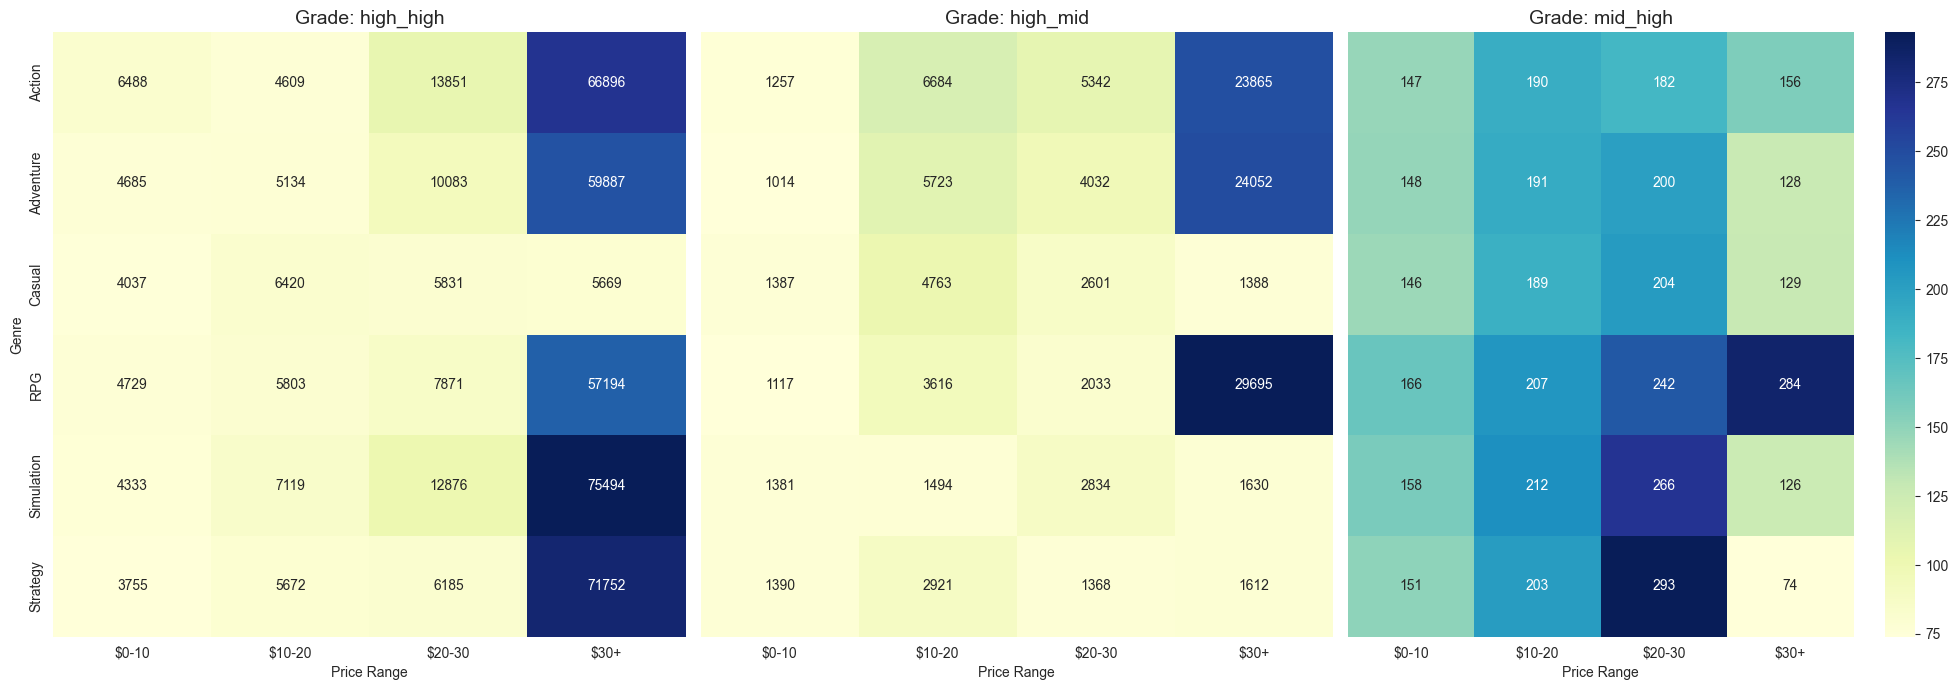

performance_grade genres_list price_range   평균_흥행
        high_high      Action       $0-10  6487.9
        high_high      Action      $10-20  4608.5
        high_high      Action      $20-30 13851.4
        high_high      Action        $30+ 66896.5
        high_high   Adventure       $0-10  4684.7
        high_high   Adventure      $10-20  5133.9
        high_high   Adventure      $20-30 10082.9
        high_high   Adventure        $30+ 59886.8
        high_high      Casual       $0-10  4037.1
        high_high      Casual      $10-20  6419.6
        high_high      Casual      $20-30  5831.3
        high_high      Casual        $30+  5669.0
        high_high         RPG       $0-10  4729.0
        high_high         RPG      $10-20  5803.2
        high_high         RPG      $20-30  7871.3
        high_high         RPG        $30+ 57194.1
        high_high  Simulation       $0-10  4332.9
        high_high  Simulation      $10-20  7119.1
        high_high  Simulation      $20-30 12875.8


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_path = '../../../../data/preprocessed/'
file_name = 'steam_indie_games_graded.csv'
file_path = os.path.join(base_path, file_name)

if not os.path.exists(file_path):
    file_path = './' + file_name

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

target_grades = ['high_high', 'high_mid', 'mid_high']
df_target = df[df['performance_grade'].isin(target_grades)].copy()

df_target['genres_list'] = df_target['genres'].fillna('Unknown').str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

bins = [-1, 10, 20, 30, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df_exploded['price_range'] = pd.cut(df_exploded['price'].fillna(0), bins=bins, labels=labels)

stats = df_exploded.groupby(['performance_grade', 'genres_list', 'price_range'], observed=False).agg(
    평균_흥행=('total_reviews', 'mean')
).reset_index()

grades = ['high_high', 'high_mid', 'mid_high']
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

for i, grade in enumerate(grades):
    subset = stats[stats['performance_grade'] == grade]
    pivoted = subset.pivot(index='genres_list', columns='price_range', values='평균_흥행')
    sns.heatmap(pivoted, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[i], cbar=(i == 2))
    axes[i].set_title(f"Grade: {grade}", fontsize=14)
    axes[i].set_xlabel("Price Range")
    if i == 0:
        axes[i].set_ylabel("Genre")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

print(stats[stats['평균_흥행'] > 0].round(1).to_string(index=False))

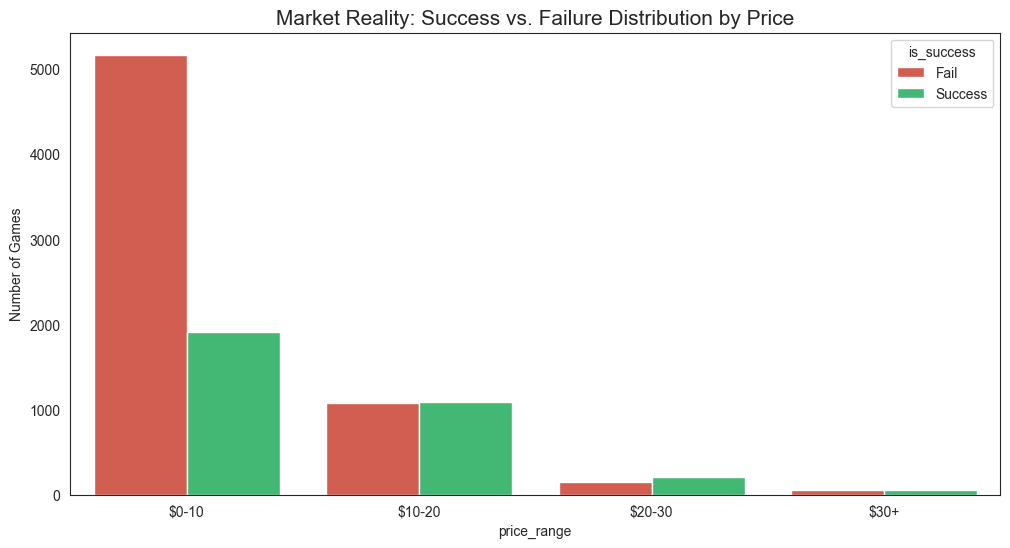

### 가격 구간별 생존율 리포트
is_success   Fail  Success  성공률(%)
price_range                       
$0-10        5170     1911   26.99
$10-20       1075     1083   50.19
$20-30        143      207   59.14
$30+           49       54   52.43


In [ ]:
base_path = '../../../../data/preprocessed/'
df = pd.read_csv(base_path + 'steam_indie_games_graded.csv')
df.columns = df.columns.str.strip()

# 1. 그룹 정의: 흥행군(HH, HM, MH) vs 비흥행군(나머지)
success_grades = ['high_high', 'high_mid', 'mid_high']
df['is_success'] = df['performance_grade'].isin(success_grades).map({True: 'Success', False: 'Fail'})

# 2. 가격 구간 설정
bins = [-1, 10, 20, 30, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df['price_range'] = pd.cut(df['price'].fillna(0), bins=bins, labels=labels)

# 3. 가격대별 성공률 및 실패 지표 집계
comparison = df.groupby(['price_range', 'is_success'], observed=False).agg(
    게임_수=('appid', 'count'),
    평균_리뷰=('total_reviews', 'mean'),
    평균_긍정률=('positive_rate', 'mean')
).reset_index()

# 4. 시각화: 가격대별 성공/실패 분포
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison, x='price_range', y='게임_수', hue='is_success', palette={'Success': '#2ecc71', 'Fail': '#e74c3c'})
plt.title('Market Reality: Success vs. Failure Distribution by Price', fontsize=15)
plt.ylabel('Number of Games')
plt.show()

print("### 가격 구간별 생존율 리포트")
pivot_count = comparison.pivot(index='price_range', columns='is_success', values='게임_수')
pivot_count['성공률(%)'] = (pivot_count['Success'] / (pivot_count['Success'] + pivot_count['Fail']) * 100).round(2)
print(pivot_count)

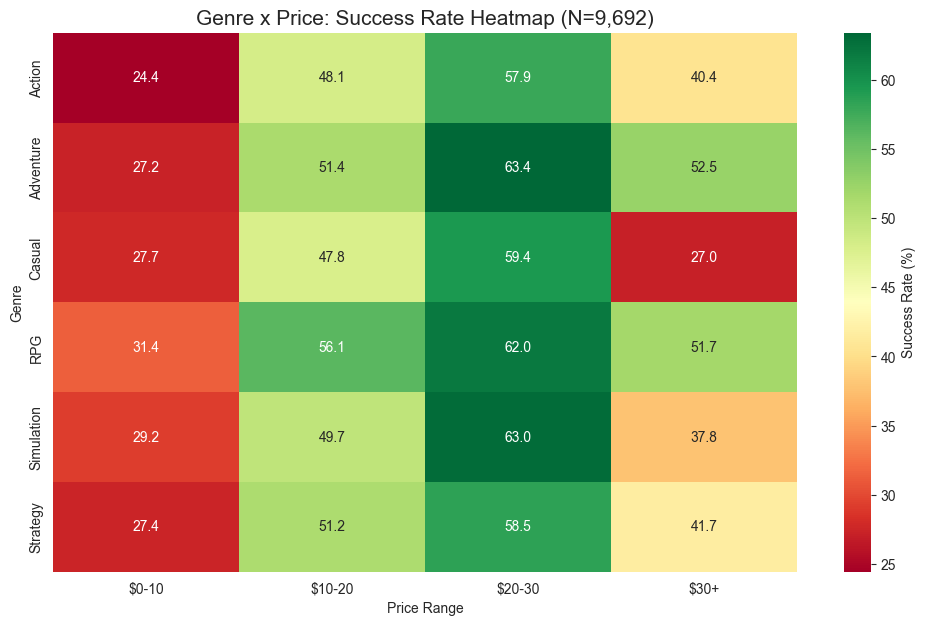


비흥행군(Fail) 장르 x 가격대별 상세 분석 (반면교사)
genres_list price_range  게임_수  평균_긍정률  평균_리뷰수   최대_리뷰수
     Action       $0-10  2194   81.97   59.78  10338.0
     Action      $10-20   479   78.03  683.99 227104.0
     Action      $20-30    69   71.84  423.26   9215.0
     Action        $30+    28   71.76  170.07   2223.0
  Adventure       $0-10  2414   80.72   56.34  10338.0
  Adventure      $10-20   567   78.93  551.31 227104.0
  Adventure      $20-30    75   74.22  410.28  12826.0
  Adventure        $30+    28   69.47  127.75   1728.0
     Casual       $0-10  2348   83.54   50.85  16969.0
     Casual      $10-20   353   78.64  100.37   1656.0
     Casual      $20-30    41   75.61  100.54    863.0
     Casual        $30+    27   67.32   39.70    459.0
        RPG       $0-10   925   78.64   97.26  16969.0
        RPG      $10-20   284   76.65 1031.14 227104.0
        RPG      $20-30    52   72.35  588.33  12826.0
        RPG        $30+    14   76.58  316.50   2223.0
 Simulation       $0-10  1198 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_path = '../../../../data/preprocessed/'
file_name = 'steam_indie_games_graded.csv'
file_path = os.path.join(base_path, file_name)
if not os.path.exists(file_path): file_path = './' + file_name

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

success_grades = ['high_high', 'high_mid', 'mid_high']
df['is_success'] = df['performance_grade'].isin(success_grades).astype(int)

df['genres_list'] = df['genres'].fillna('Unknown').str.split(',')
df_exploded = df.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

bins = [-1, 10, 20, 30, float('inf')]
labels = ['$0-10', '$10-20', '$20-30', '$30+']
df_exploded['price_range'] = pd.cut(df_exploded['price'].fillna(0), bins=bins, labels=labels)

success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_success'].mean().unstack() * 100

plt.figure(figsize=(12, 7))
sns.heatmap(success_map, annot=True, fmt=".1f", cmap="RdYlGn", cbar_kws={'label': 'Success Rate (%)'})
plt.title('Genre x Price: Success Rate Heatmap (N=9,692)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()

fail_traits_genre = df_exploded[df_exploded['is_success'] == 0].groupby(['genres_list', 'price_range'], observed=False).agg(
    게임_수=('appid', 'count'),
    평균_긍정률=('positive_rate', 'mean'),
    평균_리뷰수=('total_reviews', 'mean'),
    최대_리뷰수=('total_reviews', 'max')
).reset_index()

print("\n" + "="*80)
print("비흥행군(Fail) 장르 x 가격대별 상세 분석 (반면교사)")
print("="*80)
print(fail_traits_genre.round(2).to_string(index=False))
print("="*80)